<a href="https://colab.research.google.com/github/Nabialiyefha/Machine-Learning/blob/main/Online_Retail_Data_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## **Project Overview: Online Retail Customer Segmentation**

### **Dataset**

* **Dataset** --> UCI Online Retail II


* **Source**  --> https://archive.ics.uci.edu/dataset/502/online+retail+ii

* **Columns:**

  * `Invoice` – faktura nömrəsi
  * `StockCode` – məhsul kodu
  * `Description` – məhsulun adı
  * `Quantity` – satılan ədəd
  * `InvoiceDate` – satış tarixi
  * `Price` – məhsulun qiyməti (£)
  * `Customer ID` – unikal müştəri identifikatoru
  * `Country` – müştərinin ölkəsi

* **Features added:**

  * TotalPrice = Quantity * Price
  * Time-based features: Month, DayOfWeek, Hour

---

### **Problem Statement**

* Müştəri seqmentləşdirməsi (**Customer Segmentation**) biznes üçün vacibdir.
* Məqsəd: Müştəriləri **RFM analizi** (Recency, Frequency, Monetary) əsasında qruplaşdırmaq və **loyal**, **at-risk**, **lost** müştəriləri müəyyən etmək.

* Suallar:

  * Hansı müştərilər daha çox alış-veriş edir?
  * Hansı müştərilər risk altındadır və itirilə bilər?
  * Biznesin gəlirini artırmaq üçün hansı seqmentlərə diqqət yetirmək lazımdır?

---

### **Objectives**

1. Datanı təmizləmək və analiz üçün hazır hala gətirmək.
2. RFM features yaratmaq:

   * **Recency:** Müştərinin son alış tarixi ilə snapshot arasındakı gün sayı
   * **Frequency:** Müştərinin alış sayı
   * **Monetary:** Müştərinin xərclədiyi ümumi məbləğ
3. K-Means clustering ilə müştəriləri seqmentləşdirmək.
4. Seqmentləri biznes üçün anlaşılır adlarla təyin etmək:

   * `Champions`, `Loyal Customers`, `At Risk`, `Lost`
5. Vizualizasiya və analitik insightlar təqdim etmək:

   * Top məhsullar, top ölkələr, aylıq gəlir, gün və saat üzrə satış trendi
   * 3D RFM scatter plot
6. Müştəri seqmentlərinin davranışını təhlil etmək, risk müştəriləri müəyyən etmək.

---

### **Methodology / Approach**

1. **Data Cleaning & Preprocessing:**

   * Null dəyərlərin, mənfi Quantity və Price-lərin silinməsi
   * Invoice və StockCode filtr tətbiqi
   * TotalPrice və time-based features əlavə edilməsi

2. **Exploratory Data Analysis (EDA):**

   * Gəlir, satış həcmi, ölkələr üzrə pay, top məhsullar
   * Saat və gün üzrə satış nümunələrinin vizuallaşdırılması

3. **RFM Analysis:**

   * Müştərilərin Recency, Frequency, Monetary qiymətləndirilməsi
   * K-Means clustering ilə seqmentləşdirmə

4. **Segment Profiling & Visualization:**

   * Seqmentlərin ölçüsü, ortalama RFM dəyərləri
   * Pie chart və normalized bar chart ilə seqmentlərin müqayisəsi

---

### **Outcome / Results**

* Müştərilər 4 seqmentə ayrıldı: `Champions`, `Loyal Customers`, `At Risk`, `Lost`.
* Biznes insightları:

  * `Champions` seqmenti ən çox gəlir gətirir
  * `At Risk` və `Lost` seqmentlərinə xüsusi marketing strategiyaları tətbiq edilə bilər





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_excel("/content/online_retail_II.xlsx", sheet_name=0)

In [ ]:
df.shape

(525461, 8)

In [ ]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [ ]:
# CustomerID və Description sütunlarında boş olanları silirik
df_cleaned = df.dropna(subset=['Customer ID', 'Description']).copy()

# Nəticəni yoxlayaq
df_cleaned.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [ ]:
# --- Sample rows where Customer ID is missing ---
df[df['Customer ID'].isna()].head(8)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom


In [ ]:
# --- Negative Quantity (returns / cancellations) ---
df[df['Quantity'] < 0].head(8)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia


In [ ]:
# Mənfi Quantity olan sətirləri çıxarırıq
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0].copy()

print(f"Rows after removing negative Quantity: {len(df_cleaned)}")

Rows after removing negative Quantity: 407695


In [ ]:
df_cleaned = df_cleaned[df_cleaned['Price'] > 0].copy()

In [ ]:
# --- Invoice prefixes ---
df['Invoice'] = df['Invoice'].astype(str)
print('Unique non-digit prefixes:', df['Invoice'].str.replace(r'\d', '', regex=True).unique())

# C = cancellations, A = bad-debt adjustments
print(f'C (cancellation) : {df["Invoice"].str.startswith("C").sum():,}')
print(f'A (adjustment)   : {df["Invoice"].str.startswith("A").sum():,}')

Unique non-digit prefixes: ['' 'C' 'A']
C (cancellation) : 10,206
A (adjustment)   : 3


In [ ]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
# --- Non-standard StockCodes ---
df['StockCode'] = df['StockCode'].astype(str)
valid_mask = (
    df['StockCode'].str.match(r'^\d{5}$') |
    df['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$')
)
print('Non-standard StockCodes:', df[~valid_mask]['StockCode'].unique())

Non-standard StockCodes: ['POST' 'D' 'DCGS0058' 'DCGS0068' 'DOT' 'M' 'DCGS0004' 'DCGS0076' 'C2'
 'BANK CHARGES' 'DCGS0003' 'TEST001' 'gift_0001_80' 'DCGS0072'
 'gift_0001_20' 'DCGS0044' 'TEST002' 'gift_0001_10' 'gift_0001_50'
 'DCGS0066N' 'gift_0001_30' 'PADS' 'ADJUST' 'gift_0001_40' 'gift_0001_60'
 'gift_0001_70' 'gift_0001_90' 'DCGSSGIRL' 'DCGS0006' 'DCGS0016'
 'DCGS0027' 'DCGS0036' 'DCGS0039' 'DCGS0060' 'DCGS0056' 'DCGS0059' 'GIFT'
 'DCGSLBOY' 'm' 'DCGS0053' 'DCGS0062' 'DCGS0037' 'DCGSSBOY' 'DCGSLGIRL'
 'S' 'DCGS0069' 'DCGS0070' 'DCGS0075' 'B' 'DCGS0041' 'ADJUST2' '47503J '
 'C3' 'SP1002' 'AMAZONFEE']


In [ ]:
df_cleaned = df_cleaned[
    df_cleaned['StockCode'].str.match(r'^\d{5}$') |
    df_cleaned['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$')
].copy()

print(f"Rows after StockCode filtering: {len(df_cleaned)}")

Rows after StockCode filtering: 55393


In [ ]:
cleaned = df.copy()
cleaned['Invoice']   = cleaned['Invoice'].astype(str)
cleaned['StockCode'] = cleaned['StockCode'].astype(str)
cleaned = cleaned[cleaned['Invoice'].str.match(r'^\d{6}$')]
sc_mask = (
    cleaned['StockCode'].str.match(r'^\d{5}$') |
    cleaned['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') |
    (cleaned['StockCode'] == 'PADS')
)
cleaned.dropna(subset=['Customer ID'], inplace=True)
cleaned = cleaned[cleaned['Quantity'] > 0]
cleaned = cleaned[cleaned['Price'] > 0]
cleaned['Customer ID']  = cleaned['Customer ID'].astype(int)
cleaned['InvoiceDate']  = pd.to_datetime(cleaned['InvoiceDate'])
cleaned.drop_duplicates(inplace=True)
cleaned['SalesLineTotal'] = cleaned['Quantity'] * cleaned['Price']


In [ ]:
assert cleaned.isnull().sum().sum() == 0, 'Still has nulls!'
assert (cleaned['Quantity'] > 0).all(), 'Still has negative quantity!'
assert (cleaned['Price'] > 0).all(), 'Still has non-positive price!'
cleaned['TotalPrice'] = cleaned['Quantity'] * cleaned['Price']
cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID,SalesLineTotal,TotalPrice
count,400916.000000,400916,400916.000000,400916.000000,400916.000000,400916.000000
mean,13.767418,2010-07-01 05:01:16.167027712,3.305826,15361.544074,21.945330,21.945330
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,0.001000
25%,2.000000,2010-03-26 13:28:00,1.250000,13985.000000,5.000000,5.000000
50%,5.000000,2010-07-09 10:26:00,1.950000,15311.000000,12.500000,12.500000
75%,12.000000,2010-10-14 13:58:45,3.750000,16805.000000,19.500000,19.500000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,15818.400000
std,97.638385,NaN,35.047719,1680.635823,77.758075,77.758075


In [ ]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Invoice         400916 non-null  object        
 1   StockCode       400916 non-null  object        
 2   Description     400916 non-null  object        
 3   Quantity        400916 non-null  int64         
 4   InvoiceDate     400916 non-null  datetime64[ns]
 5   Price           400916 non-null  float64       
 6   Customer ID     400916 non-null  int64         
 7   Country         400916 non-null  object        
 8   SalesLineTotal  400916 non-null  float64       
 9   TotalPrice      400916 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 33.6+ MB


In [ ]:
cleaned.drop(columns=['SalesLineTotal'], inplace=True)

In [ ]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  int64         
 7   Country      400916 non-null  object        
 8   TotalPrice   400916 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.6+ MB


In [ ]:
cleaned.shape

(400916, 9)

FEATURE(EDA)


In [ ]:
cleaned['Month'] = cleaned['InvoiceDate'].dt.to_period('M')

In [ ]:
cleaned['DayOfWeek'] = cleaned['InvoiceDate'].dt.day_name()

In [ ]:
cleaned

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90,2010-12,Thursday
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,Thursday
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,Thursday
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50,2010-12,Thursday


In [ ]:
cleaned['Hour'] = cleaned['InvoiceDate'].dt.hour

In [ ]:
print(f'Unique customers : {cleaned["Customer ID"].nunique():,}')

Unique customers : 4,312


In [ ]:
print(f'Unique invoices  : {cleaned["Invoice"].nunique():,}')

Unique invoices  : 19,213


In [ ]:
print(f'Unique products  : {cleaned["StockCode"].nunique():,}')

Unique products  : 4,017


In [ ]:
print(f'Countries        : {cleaned["Country"].nunique()}')

Countries        : 37


In [ ]:
print(f'Total revenue    : £{cleaned["TotalPrice"].sum():,.2f}')

Total revenue    : £8,798,233.74


In [ ]:
cleaned

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,Tuesday,7
...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90,2010-12,Thursday,20
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,Thursday,20
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,Thursday,20
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50,2010-12,Thursday,20


**Exploration Summary**

| Issue | Description | Action |
|---|---|---|
| Missing **Customer ID** | ~25% of rows have no customer | Drop |
| Negative **Quantity** | Returns & cancellations | Drop |
| **Invoice** starts with `C` | Cancellation transactions | Drop |
| **Invoice** starts with `A` | Bad-debt adjustments | Drop |
| Non-standard **StockCode** | Postage, manual, test entries | Drop |
| **Price == 0** | Free / test items | Drop |

In [ ]:
monthly = cleaned.groupby('Month')['TotalPrice'].sum().reset_index()

In [ ]:
monthly['Month'] = monthly['Month'].astype(str)

In [ ]:
import matplotlib.ticker as mticker

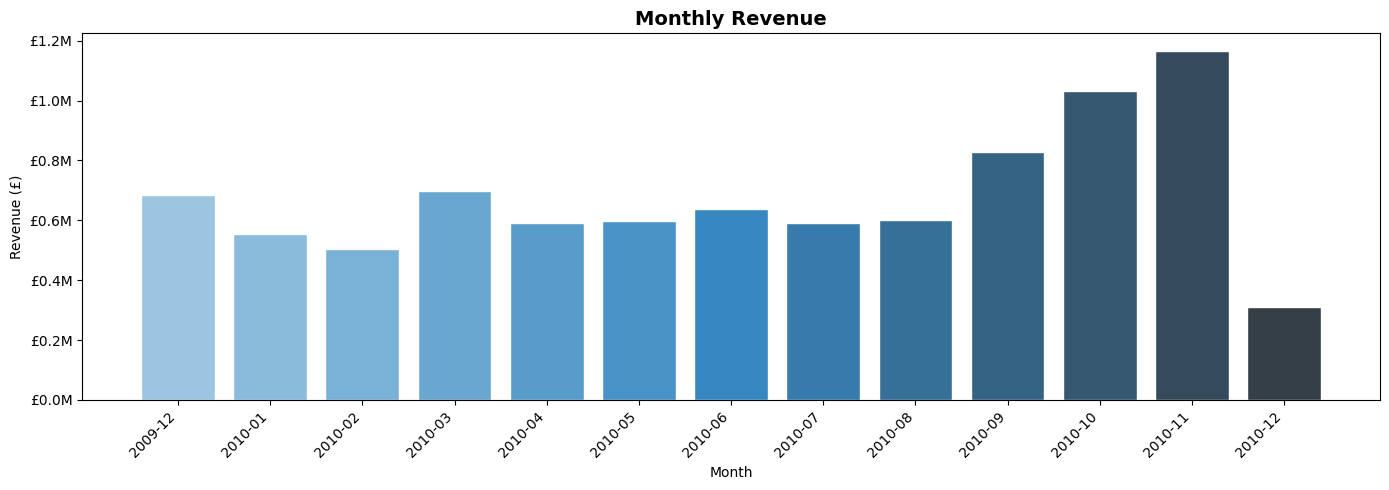

In [ ]:
plt.figure(figsize=(14, 5))
plt.bar(monthly['Month'], monthly['TotalPrice'],
        color=sns.color_palette('Blues_d', len(monthly)), edgecolor='white')
plt.title('Monthly Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

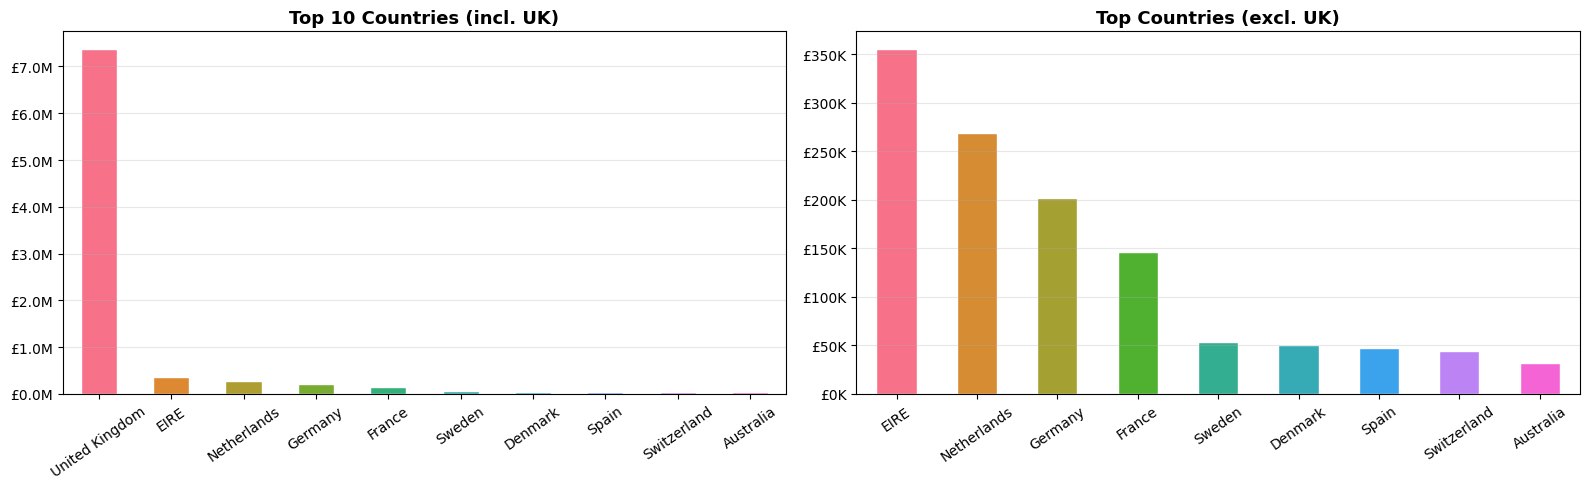

In [ ]:
# --- Top Countries ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10 = cleaned.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top10_no_uk = top10.drop('United Kingdom', errors='ignore')

for ax, data, title, fmt in [
    (axes[0], top10,       'Top 10 Countries (incl. UK)', lambda x,_: f'£{x/1e6:.1f}M'),
    (axes[1], top10_no_uk, 'Top Countries (excl. UK)',    lambda x,_: f'£{x/1e3:.0f}K')
]:
    data.plot(kind='bar', ax=ax, color=sns.color_palette('husl', len(data)), edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

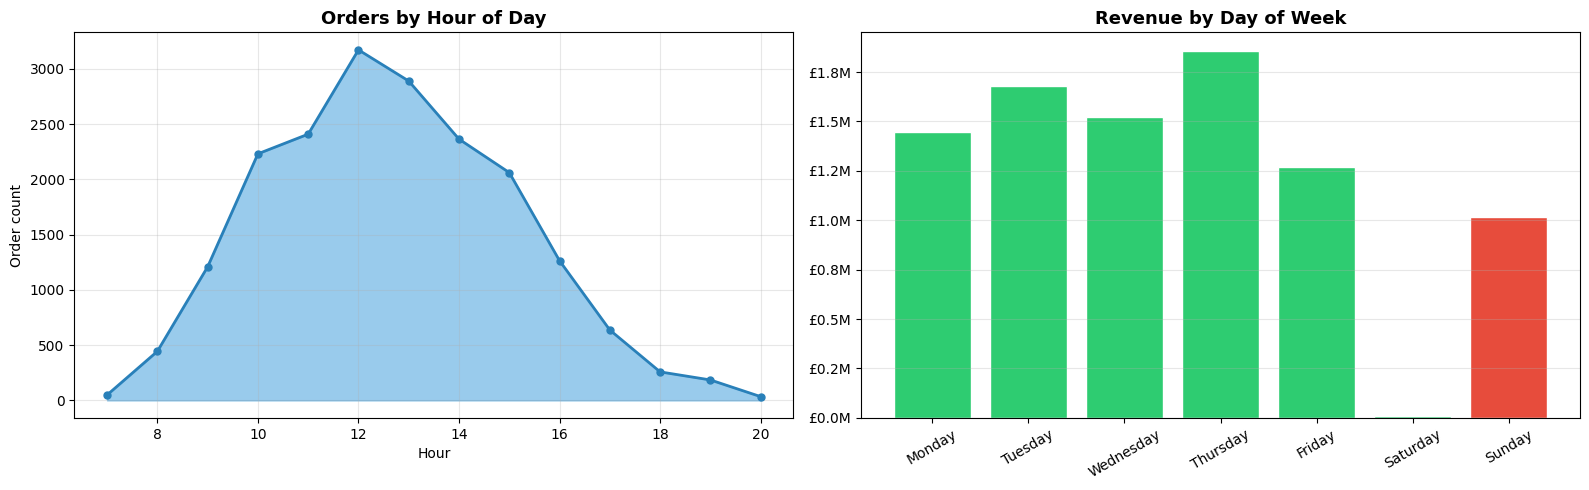

In [ ]:
# --- Hourly & Daily Patterns ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Orders by hour
hourly = cleaned.groupby('Hour')['Invoice'].nunique()
axes[0].fill_between(hourly.index, hourly.values, alpha=0.5, color='#3498db')
axes[0].plot(hourly.index, hourly.values, color='#2980b9', lw=2, marker='o', ms=5)
axes[0].set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Order count')
axes[0].grid(True, alpha=0.3)

# Revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = cleaned.groupby('DayOfWeek')['TotalPrice'].sum().reindex(dow_order)
colors    = ['#e74c3c' if d == 'Sunday' else '#2ecc71' for d in dow_order]
axes[1].bar(dow_rev.index, dow_rev.values, color=colors, edgecolor='white')
axes[1].set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

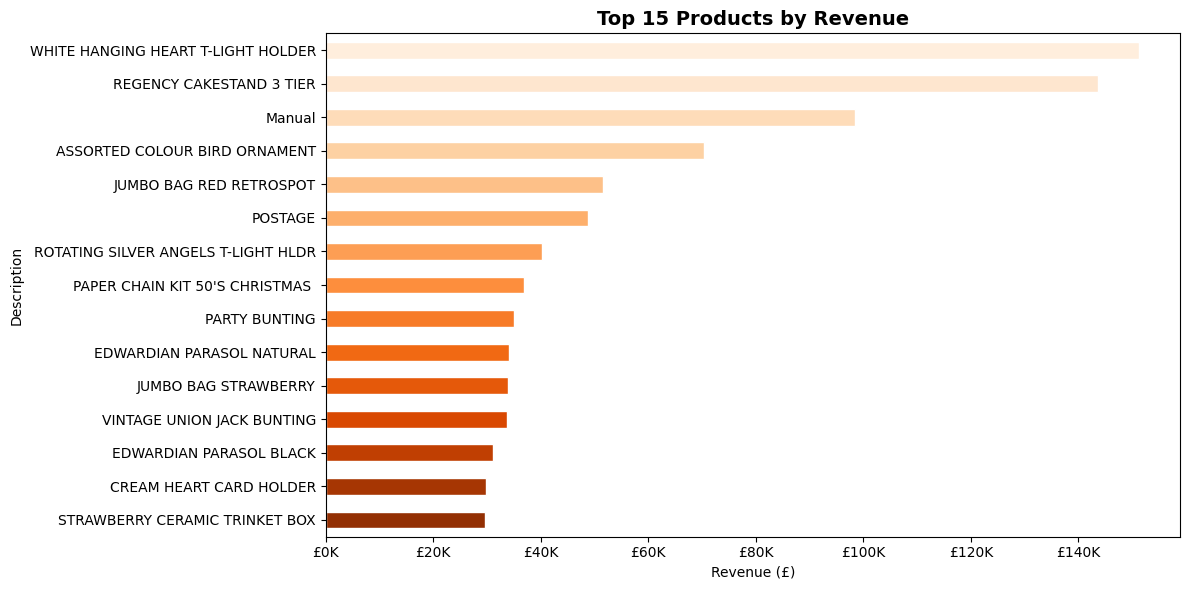

In [ ]:
top_prod = (cleaned.groupby('Description')['TotalPrice']
                   .sum().sort_values(ascending=True).tail(15))

plt.figure(figsize=(12, 6))
top_prod.plot(kind='barh',
              color=sns.color_palette('Oranges_r', 15),
              edgecolor='white')
plt.title('Top 15 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

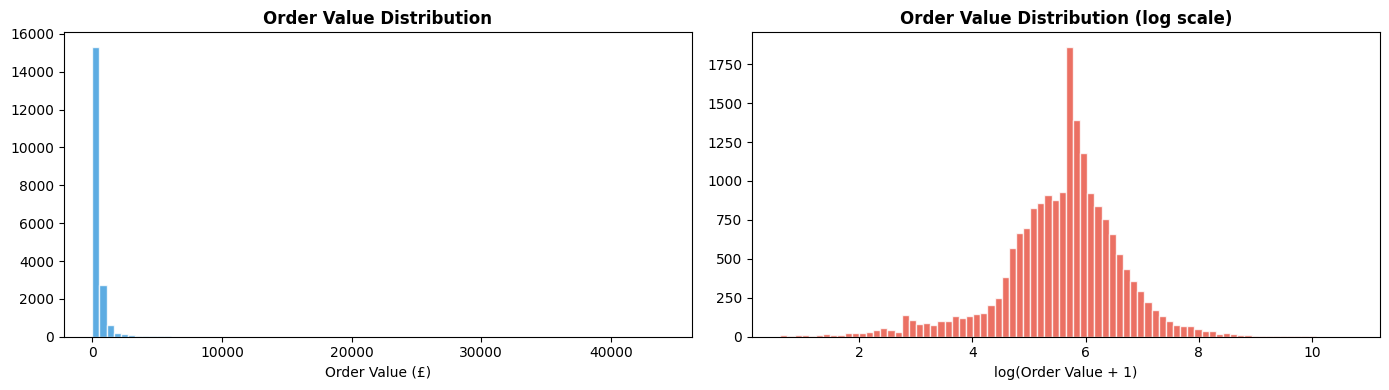

Median order value : £302.90
Mean order value   : £457.93


In [ ]:
order_totals = cleaned.groupby('Invoice')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(order_totals, bins=80, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Order Value Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Order Value (£)')

axes[1].hist(np.log1p(order_totals), bins=80, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title('Order Value Distribution (log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Order Value + 1)')

plt.tight_layout()
plt.show()
print(f'Median order value : £{order_totals.median():.2f}')
print(f'Mean order value   : £{order_totals.mean():.2f}')

Feature Engineering

In [ ]:
from datetime import timedelta

In [ ]:
# Snapshot date: one day after the last transaction
SNAPSHOT = cleaned['InvoiceDate'].max() + timedelta(days=1)
print(f'Snapshot date: {SNAPSHOT.date()}')

# --- Core RFM ---
rfm = cleaned.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (SNAPSHOT - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

# --- Extended features ---
extra = cleaned.groupby('Customer ID').agg(
    AvgOrderValue      = ('TotalPrice',  'mean'),
    TotalItems         = ('Quantity',    'sum'),
    UniqueProducts     = ('StockCode',   'nunique'),
    UniqueCountries    = ('Country',     'nunique'),
    FirstPurchase      = ('InvoiceDate', 'min'),
    LastPurchase       = ('InvoiceDate', 'max'),
).reset_index()

extra['CustomerAge']    = (extra['LastPurchase']  - extra['FirstPurchase']).dt.days
extra['DaysSinceFirst'] = (SNAPSHOT - extra['FirstPurchase']).dt.days
extra.drop(['FirstPurchase','LastPurchase'], axis=1, inplace=True)

rfm = rfm.merge(extra, on='Customer ID')

# --- Derived ratios ---
rfm['RevenuePerOrder']   = rfm['Monetary']  / rfm['Frequency']
rfm['ItemsPerOrder']     = rfm['TotalItems'] / rfm['Frequency']
rfm['PurchaseVelocity']  = rfm['Frequency']  / (rfm['DaysSinceFirst'] + 1) * 30

print(f'Customers : {len(rfm):,}')
print(f'Features  : {rfm.shape[1]}')
rfm.head(6)

Snapshot date: 2010-12-10
Customers : 4,312
Features  : 13


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,UniqueProducts,UniqueCountries,CustomerAge,DaysSinceFirst,RevenuePerOrder,ItemsPerOrder,PurchaseVelocity
0,12346,165,11,372.86,11.298788,70,26,1,196,361,33.896364,6.363636,0.911602
1,12347,3,2,1323.32,18.638310,828,70,1,37,40,661.660000,414.000000,1.463415
2,12348,74,1,222.16,11.108000,373,20,1,0,74,222.160000,373.000000,0.400000
3,12349,43,3,2671.14,26.187647,993,90,1,181,225,890.380000,331.000000,0.398230
4,12351,11,1,300.93,14.330000,261,21,1,0,11,300.930000,261.000000,2.500000
5,12352,11,2,343.80,19.100000,188,18,1,16,28,171.900000,94.000000,2.068966


In [ ]:
rfm[['Recency','Frequency','Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,4312.00,4312.00,4312.00
mean,91.17,4.46,2040.41
std,96.86,8.17,8911.76
min,1.00,1.00,2.95
25%,18.00,1.00,307.19
50%,53.00,2.00,701.62
75%,136.00,5.00,1714.93
max,374.00,205.00,349164.35


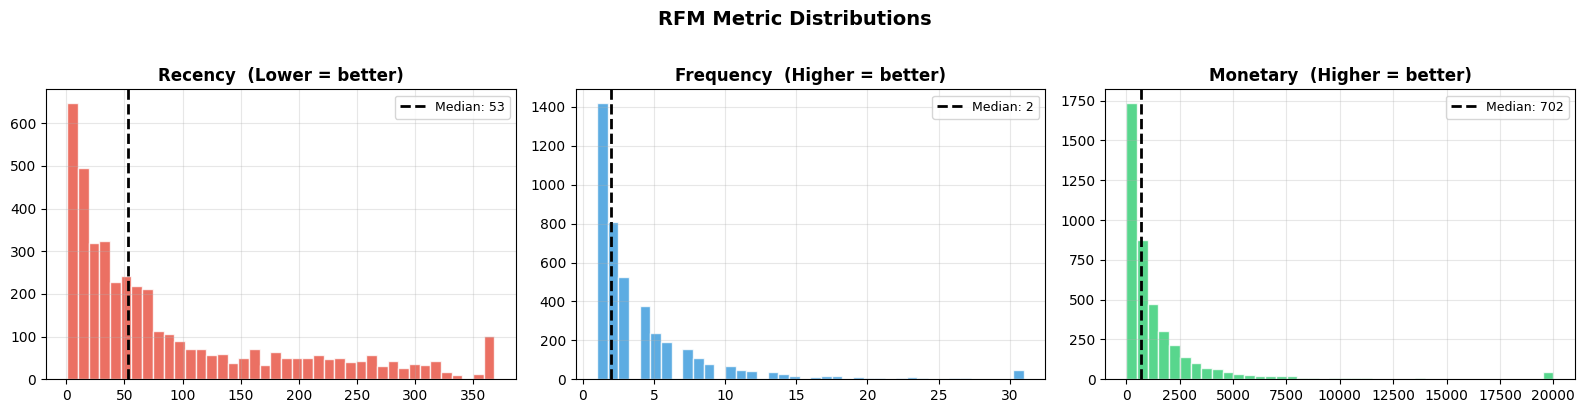

In [ ]:
# --- RFM Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, note in [
    (axes[0], 'Recency',   '#e74c3c', 'Lower = better'),
    (axes[1], 'Frequency', '#3498db', 'Higher = better'),
    (axes[2], 'Monetary',  '#2ecc71', 'Higher = better'),
]:
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.median(), ls='--', lw=2, color='black',
               label=f'Median: {data.median():.0f}')
    ax.set_title(f'{col}  ({note})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('RFM Metric Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

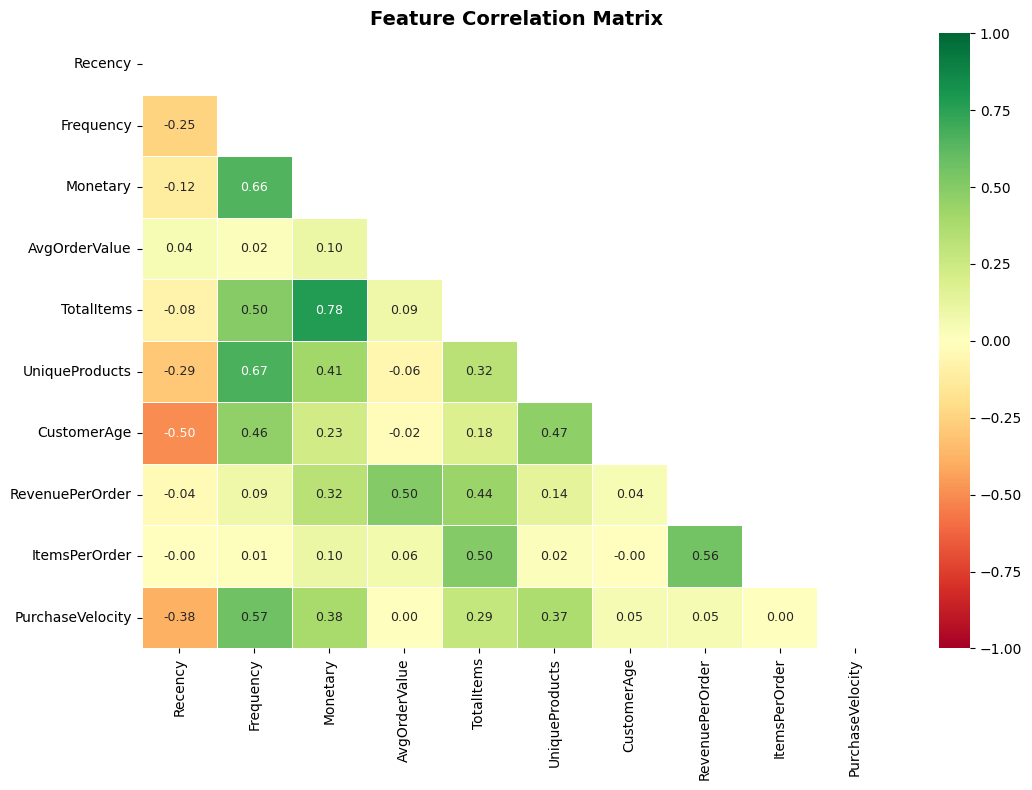

In [ ]:
feat_cols = ['Recency','Frequency','Monetary','AvgOrderValue',
             'TotalItems','UniqueProducts','CustomerAge',
             'RevenuePerOrder','ItemsPerOrder','PurchaseVelocity']

plt.figure(figsize=(11, 8))
corr = rfm[feat_cols].corr()  #Pearson correlation(-1 ile 1)
mask = np.triu(np.ones_like(corr, dtype=bool))  #təkrar məlumatı gizlə
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Recency → son alışdan neçə gün keçib

# Frequency → neçə dəfə alış edib

# Monetary → nə qədər pul xərcləyib

# Məsələn, recency ilə frequency arsındakı əlaqəyə baxsaq, -0,25 görürük. Bu da o deməkdir ki,
# uzun müddət alış etməyən müştərilər daha az alış edir.

In [ ]:
# --- Prepare RFM for clustering (log + StandardScaler) ---
rfm_clust = rfm[['Recency','Frequency','Monetary']].copy()
rfm_clust['Monetary']  = np.log1p(rfm_clust['Monetary'])
rfm_clust['Frequency'] = np.log1p(rfm_clust['Frequency'])

scaler_rfm  = StandardScaler()
rfm_scaled  = scaler_rfm.fit_transform(rfm_clust)

print('RFM features scaled (log + StandardScaler).')

RFM features scaled (log + StandardScaler).


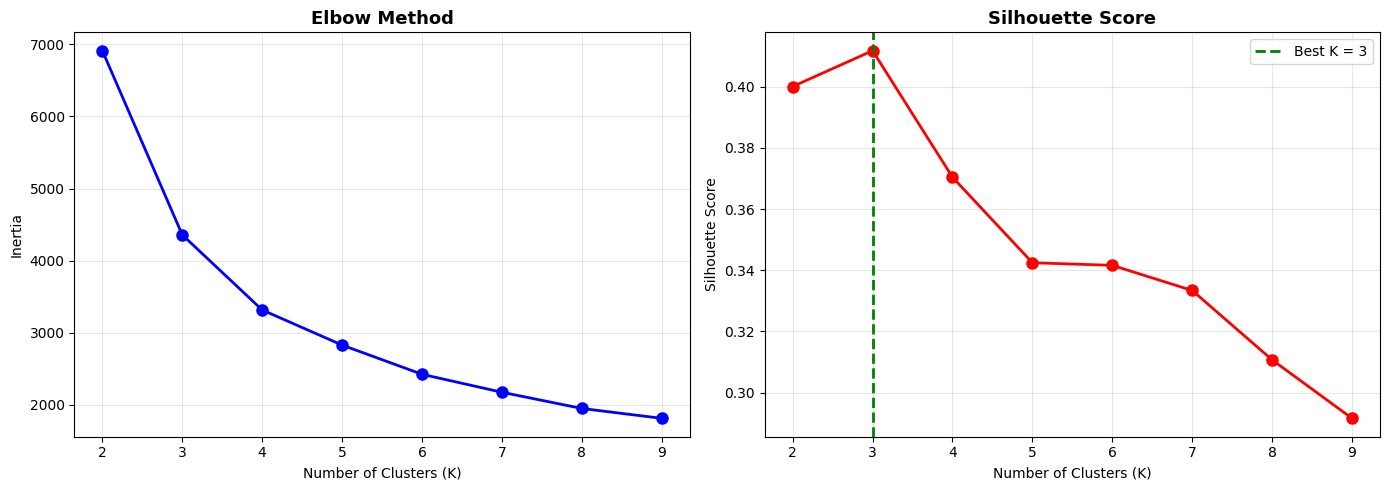

Optimal K = 3  (Silhouette = 0.4118)


In [ ]:
# --- Elbow + Silhouette ---
inertias, silhouettes = [], []
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias, 'bo-', lw=2, ms=8)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
axes[1].plot(K_RANGE, silhouettes, 'ro-', lw=2, ms=8)
axes[1].axvline(best_k, ls='--', color='green', lw=2, label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Optimal K = {best_k}  (Silhouette = {max(silhouettes):.4f})')

In [ ]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'Silhouette Score (K={K_FINAL}): {silhouette_score(rfm_scaled, rfm["Cluster"]):.4f}')

# Cluster RFM means
cluster_means = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print('\nCluster means:')
cluster_means

# Cluster 3

# Recency ↓

# Frequency ↑

# Monetary ↑    -->   VIP müştərilər


# Cluster 1

# Recency ↑

# Frequency ↓

# Monetary ↓         -->  riskli və ya churn müştərilər

Silhouette Score (K=4): 0.3720

Cluster means:


,Recency,Frequency,Monetary
Cluster,,,
0,255.2,1.4,416.4
1,50.0,4.2,1588.8
2,56.8,1.5,371.2
3,22.6,15.8,9137.5


In [ ]:
# --- Assign business names ---
# Score: low Recency = good, high Frequency & Monetary = good
scores = {}
for c in range(K_FINAL):
    r = cluster_means.loc[c, 'Recency']
    f = cluster_means.loc[c, 'Frequency']
    m = cluster_means.loc[c, 'Monetary']
    scores[c] = -r + f * 10 + m / 100

ranked = sorted(scores, key=scores.get, reverse=True)   #clusterləri ən yaxşıdan ən pisə doğru sırala
segment_names = ['Champions', 'Loyal Customers', 'At Risk', 'Lost']
segment_map   = {c: n for c, n in zip(ranked, segment_names)}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

seg_counts = rfm['Segment'].value_counts()
print('Segment distribution:')
for seg, cnt in seg_counts.items():
    print(f'  {seg:<20} {cnt:>5} ({cnt/len(rfm)*100:.1f}%)')

Segment distribution:
  Loyal Customers       1486 (34.5%)
  At Risk               1313 (30.4%)
  Lost                   903 (20.9%)
  Champions              610 (14.1%)


In [ ]:
# --- Segment profile table ---
seg_profile = rfm.groupby('Segment').agg(
    Customers    = ('Customer ID',  'count'),
    Avg_Recency  = ('Recency',      'mean'),
    Avg_Frequency= ('Frequency',    'mean'),
    Avg_Monetary = ('Monetary',     'mean'),
    Total_Revenue= ('Monetary',     'sum')
).round(1)
seg_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
At Risk,1313,56.8,1.5,371.2,487439.1
Champions,610,22.6,15.8,9137.5,5573892.5
Lost,903,255.2,1.4,416.4,376002.1
Loyal Customers,1486,50.0,4.2,1588.8,2360900.1


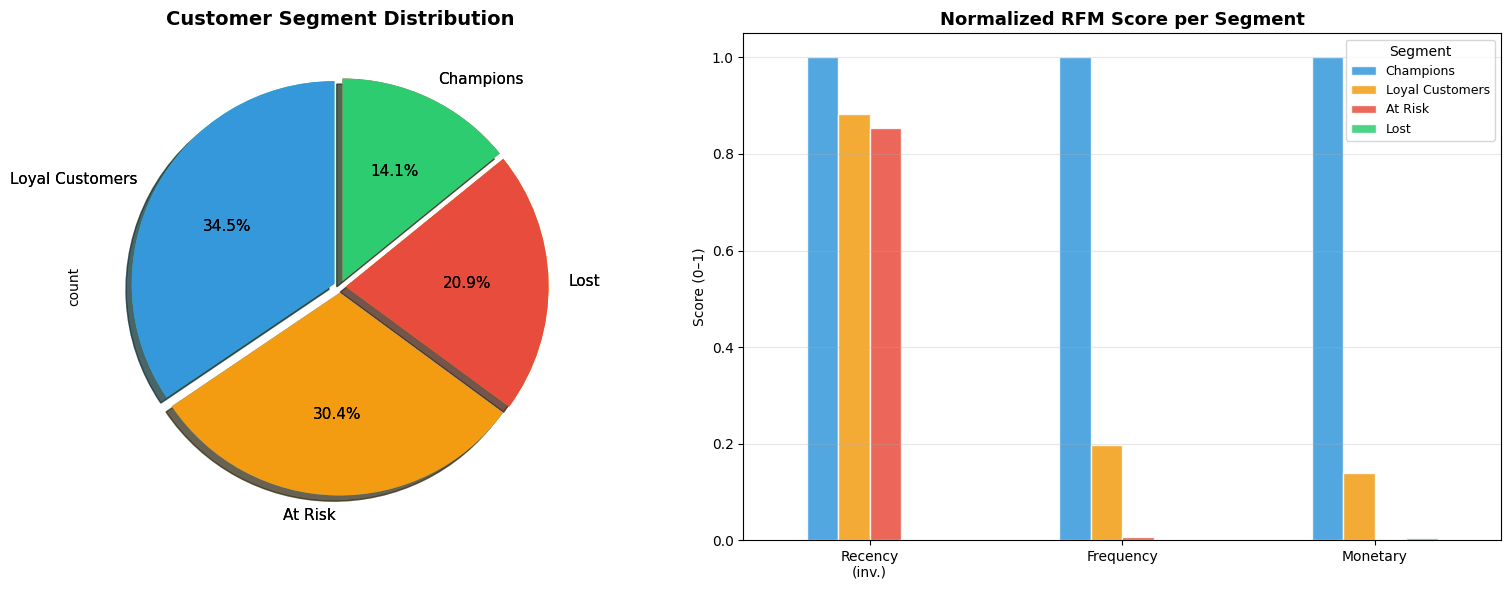

In [ ]:
# --- Segment Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

# Pie chart
seg_counts.plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=colors, startangle=90,
    explode=[0.03]*K_FINAL, shadow=True,
    textprops={'fontsize': 11}
)
axes[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

color_map = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'At Risk': '#f39c12',
    'Lost': '#e74c3c'
}

colors = [color_map[seg] for seg in seg_counts.index]

seg_counts.plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=colors, startangle=90,
    explode=[0.03]*K_FINAL, shadow=True,
    textprops={'fontsize': 11}
)
# Normalized RFM bar chart
seg_rfm  = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
seg_norm = (seg_rfm - seg_rfm.min()) / (seg_rfm.max() - seg_rfm.min())
seg_norm['Recency'] = 1 - seg_norm['Recency']   # invert: lower recency = better
seg_norm = seg_norm.loc[['Champions','Loyal Customers','At Risk','Lost']]

seg_norm.T.plot(kind='bar', ax=axes[1],
                color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Normalized RFM Score per Segment', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Recency\n(inv.)', 'Frequency', 'Monetary'], rotation=0)
axes[1].set_ylabel('Score (0–1)')
axes[1].legend(title='Segment', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
# --- Interactive 3D scatter (Plotly) ---
rfm_plot = rfm.copy()
rfm_plot['log_Monetary']  = np.log1p(rfm_plot['Monetary'])
rfm_plot['log_Frequency'] = np.log1p(rfm_plot['Frequency'])

fig = px.scatter_3d(
    rfm_plot.sample(min(2000, len(rfm_plot)), random_state=42),
    x='Recency', y='log_Frequency', z='log_Monetary',
    color='Segment',
    title='Customer Segments in 3D RFM Space',
    labels={'log_Frequency': 'log(Frequency)', 'log_Monetary': 'log(Monetary)'},
    color_discrete_sequence=colors,
    opacity=0.7, template='plotly_white',
    width=850, height=550
)
fig.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
CHURN_THRESHOLD = 90

rfm['Churned'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)
FEATURE_COLS = [
    'Frequency', 'Monetary', 'AvgOrderValue',
    'TotalItems', 'UniqueProducts', 'CustomerAge',
    'RevenuePerOrder', 'ItemsPerOrder', 'PurchaseVelocity'
]

X = rfm[FEATURE_COLS].copy()
y = rfm['Churned']

# Log-transform skewed features
LOG_COLS = ['Frequency','Monetary','TotalItems','AvgOrderValue','RevenuePerOrder']
for col in LOG_COLS:
    X[col] = np.log1p(X[col])

# Train / test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing  import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [ ]:
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing  import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [ ]:
MODELS = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':              xgb.XGBClassifier(eval_metric='logloss', random_state=42),
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in MODELS.items():
    model.fit(X_train_s, y_train)

    cv_auc  = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='roc_auc').mean()
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    rows.append({
        'Model':     name,
        'CV AUC':    round(cv_auc, 4),
        'Test AUC':  round(roc_auc_score(y_test, y_proba), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
    })

results = pd.DataFrame(rows).sort_values('Test AUC', ascending=False).set_index('Model')
results.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}')

,CV AUC,Test AUC,Accuracy,Precision,Recall,F1
Model,,,,,,
XGBoost,0.9964,0.9961,0.9699,0.9925,0.9164,0.9529
Gradient Boosting,0.9925,0.9916,0.9467,0.9879,0.8502,0.9139
Random Forest,0.9876,0.9903,0.9432,0.9917,0.8362,0.9074
Logistic Regression,0.9863,0.9810,0.9386,0.9606,0.8502,0.9020
Decision Tree,0.9680,0.9646,0.9131,0.9240,0.8049,0.8603


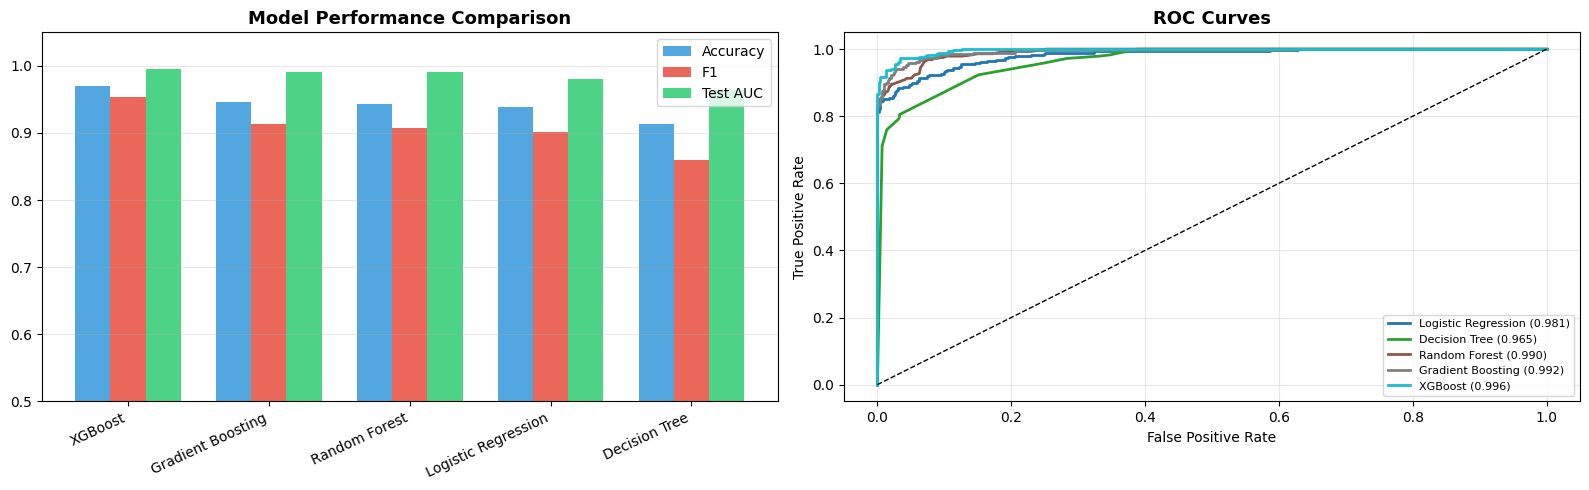

In [ ]:
# --- Comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics   = ['Accuracy', 'F1', 'Test AUC']
bar_colors= ['#3498db', '#e74c3c', '#2ecc71']
x = np.arange(len(results))
w = 0.25

for i, (m, c) in enumerate(zip(metrics, bar_colors)):
    axes[0].bar(x + i*w, results[m], w, label=m, color=c, alpha=0.85)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(results.index, rotation=25, ha='right')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend()
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# ROC curves
palette = plt.cm.tab10(np.linspace(0, 1, len(MODELS)))
for (name, model), color in zip(MODELS.items(), palette):
    yp  = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} ({auc:.3f})')

axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
print('Running GridSearchCV on XGBoost...')

param_grid = {
    'n_estimators':   [100, 200, 300],
    'max_depth':      [3, 4, 5],
    'learning_rate':  [0.05, 0.1, 0.2],
    'subsample':      [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid.fit(X_train_s, y_train)

best_model = grid.best_estimator_
print(f'\nBest params : {grid.best_params_}')
print(f'Best CV AUC : {grid.best_score_:.4f}')

Running GridSearchCV on XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV AUC : 0.9970


In [ ]:
y_pred_b  = best_model.predict(X_test_s)
y_proba_b = best_model.predict_proba(X_test_s)[:, 1]

print('=== Tuned XGBoost — Test Set Results ===')
print(f'Accuracy  : {accuracy_score(y_test,  y_pred_b):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_b):.4f}')
print(f'Recall    : {recall_score(y_test,    y_pred_b):.4f}')
print(f'F1-Score  : {f1_score(y_test,        y_pred_b):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test,   y_proba_b):.4f}')
print()


=== Tuned XGBoost — Test Set Results ===
Accuracy  : 0.9722
Precision : 0.9852
Recall    : 0.9303
F1-Score  : 0.9570
AUC-ROC   : 0.9950



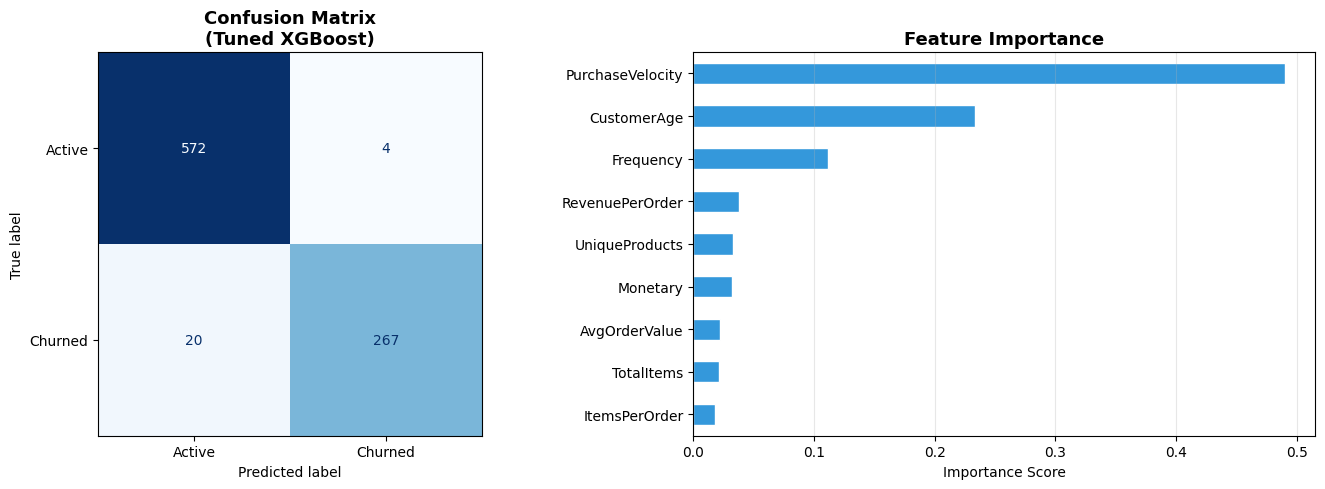

In [ ]:
# --- Confusion Matrix & Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_b)
ConfusionMatrixDisplay(cm, display_labels=['Active','Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix\n(Tuned XGBoost)', fontsize=13, fontweight='bold')

# Feature Importance
fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
fi.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

100 müştəri var:

30 churned, 70 active

Modelin nəticələri:

25 churned düzgün tapılıb (TP)

5 churn qaçırılıb (FN)

65 active düzgün tapılıb (TN)

5 active səhv churn proqnoz edilib (FP)

Confusion matrix:

	Pred Active	Pred Churned
Actual Active    	65	5

Actual Churned	5	  25

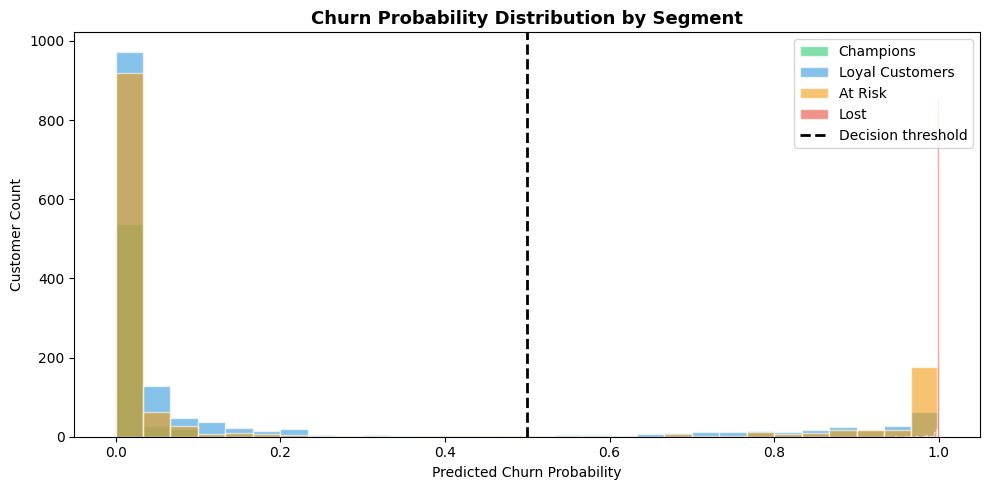

In [ ]:
# --- Churn probability distribution by segment ---
rfm['ChurnProba'] = best_model.predict_proba(
    scaler.transform(
        rfm[FEATURE_COLS].assign(**{c: np.log1p(rfm[c]) for c in LOG_COLS})
    )
)[:, 1]

plt.figure(figsize=(10, 5))
for seg, color in zip(['Champions','Loyal Customers','At Risk','Lost'], colors):
    data = rfm[rfm['Segment'] == seg]['ChurnProba']
    plt.hist(data, bins=30, alpha=0.6, label=seg, color=color, edgecolor='white')

plt.axvline(0.5, ls='--', color='black', lw=2, label='Decision threshold')
plt.title('Churn Probability Distribution by Segment', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Customer Count')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================
print('=' * 60)
print('PROJECT SUMMARY')
print('=' * 60)
print(f'Dataset          : Online Retail II (real-world UK e-commerce)')
print(f'Raw transactions : {len(df):,}')
print(f'After cleaning   : {len(cleaned):,}  ({len(cleaned)/len(df)*100:.0f}% retained)')
print(f'Unique customers : {len(rfm):,}')
print(f'Features built   : {len(FEATURE_COLS)}')
print(f'K-Means segments : {K_FINAL}')
print(f'Silhouette score : {silhouette_score(rfm_scaled, rfm["Cluster"]):.4f}')
print(f'Models compared  : {len(MODELS)}')
print(f'Best model       : Tuned XGBoost')
print(f'Test AUC-ROC     : {roc_auc_score(y_test, y_proba_b):.4f}')
print(f'Test F1-Score    : {f1_score(y_test, y_pred_b):.4f}')
print('=' * 60)

PROJECT SUMMARY
Dataset          : Online Retail II (real-world UK e-commerce)
Raw transactions : 525,461
After cleaning   : 400,916  (76% retained)
Unique customers : 4,312
Features built   : 9
K-Means segments : 4
Silhouette score : 0.3720
Models compared  : 5
Best model       : Tuned XGBoost
Test AUC-ROC     : 0.9950
Test F1-Score    : 0.9570
